<a href="https://colab.research.google.com/github/Amdzak/PCVK-Tugas-Kelompok/blob/main/Tugas_Kelompok_PCVK_P12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download dataset melalui kaggle

In [ ]:
!pip install kaggle
from google.colab import userdata
import os

try:
  os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
  os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
except Exception as e:
  print(e)

!kaggle datasets download -d moltean/fruits



Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 4.59G/4.60G [02:05<00:00, 241MB/s]
100% 4.60G/4.60G [02:05<00:00, 39.3MB/s]


extract data

In [ ]:
import zipfile
from tqdm import tqdm

zip_path = "fruits.zip"
extract_path = "fruits360"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    total_files = len(zip_ref.infolist())
    with tqdm(total=total_files, desc='Extracting') as pbar:
        for file in zip_ref.infolist():
            zip_ref.extract(file, extract_path)
            pbar.update(1)


Extracting: 100%|██████████| 283619/283619 [01:38<00:00, 2886.07it/s]


Ambil citra citra asli sesuai dengan kategori kelompok

In [ ]:
import os
import shutil

source_train = "./fruits360/fruits-360_original-size/fruits-360-original-size/Training"
source_test = "./fruits360/fruits-360_original-size/fruits-360-original-size/Test"

target_base = "./Remapped_Training/Kacang-Sitrus-Melon"

# Mapping kategori → nama folder buah
category_map = {
    "Kacang-Sitrus-Melon": [
        # Kacang
        "Caju seed", "Chestnut", "Cocos", "Hazelnut",
        "Nut", "Nut Forest", "Nut Pecan", "Pistachio", "Walnut",

        # Sitrus
        "Clementine", "Grapefruit Pink", "Grapefruit White",
        "Kumquats", "Lemon", "Lemon Meyer", "Limes",
        "Mandarine", "Orange", "Pomelo Sweetie", "Tangelo",

        # Melon
        "Cantaloupe", "Melon Piel de Sapo"
    ]
}

def find_fruit_class(folder):
    for fruit in category_map["Kacang-Sitrus-Melon"]:
        if folder.startswith(fruit):
            return fruit
    return None

# Membuat folder train/test
train_target = os.path.join(target_base, "Train")
test_target  = os.path.join(target_base, "Test")
os.makedirs(train_target, exist_ok=True)
os.makedirs(test_target, exist_ok=True)

# --- PROSES TRAIN ---
for folder in os.listdir(source_train):
    fruit = find_fruit_class(folder)
    if fruit is None:
        continue

    src_folder = os.path.join(source_train, folder)
    dst_folder = os.path.join(train_target, fruit)
    os.makedirs(dst_folder, exist_ok=True)

    for img in os.listdir(src_folder):
        shutil.copy2(os.path.join(src_folder, img), os.path.join(dst_folder, img))

# --- PROSES TEST ---
for folder in os.listdir(source_test):
    fruit = find_fruit_class(folder)
    if fruit is None:
        continue

    src_folder = os.path.join(source_test, folder)
    dst_folder = os.path.join(test_target, fruit)
    os.makedirs(dst_folder, exist_ok=True)

    for img in os.listdir(src_folder):
        shutil.copy2(os.path.join(src_folder, img), os.path.join(dst_folder, img))

print("DONE! Struktur Train/Test per buah berhasil dibuat.")


DONE! Struktur Train/Test per buah berhasil dibuat.


In [ ]:
!ls /content/Remapped_Training/Kacang-Sitrus-Melon

Test  Train


In [ ]:
!find /content/Remapped_Training -maxdepth 4 -type d -print

/content/Remapped_Training
/content/Remapped_Training/Kacang-Sitrus-Melon
/content/Remapped_Training/Kacang-Sitrus-Melon/Train
/content/Remapped_Training/Kacang-Sitrus-Melon/Train/Caju seed
/content/Remapped_Training/Kacang-Sitrus-Melon/Train/Pistachio
/content/Remapped_Training/Kacang-Sitrus-Melon/Train/Nut
/content/Remapped_Training/Kacang-Sitrus-Melon/Test
/content/Remapped_Training/Kacang-Sitrus-Melon/Test/Caju seed
/content/Remapped_Training/Kacang-Sitrus-Melon/Test/Pistachio
/content/Remapped_Training/Kacang-Sitrus-Melon/Test/Nut


# Ambil beberapa citra dari objek berbeda dan bandingkan kualitasnya berdasarkan pencahayaan dan resolusi sesuai tema masing-masing.


Ambil 3 object citra random

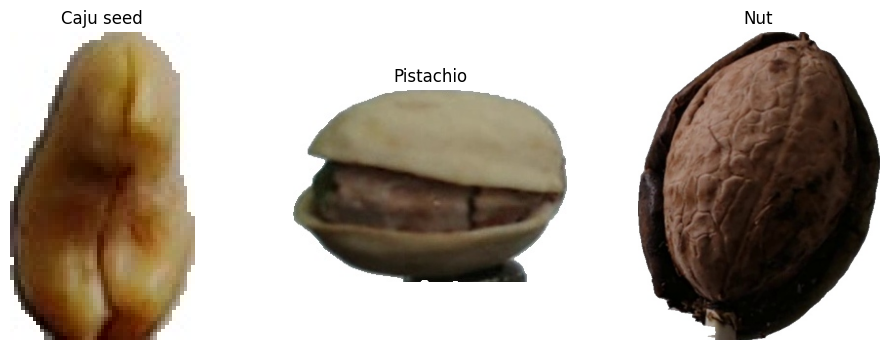

In [ ]:
import cv2
import os
import numpy as np
from skimage import filters, measure
import matplotlib.pyplot as plt

base = "/content/Remapped_Training/Kacang-Sitrus-Melon/Train"

# Ambil 1 gambar per kelas
images = {}

for cls in os.listdir(base):
    cls_path = os.path.join(base, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.png','.jpeg'))]
    if img_files:
        img_path = os.path.join(cls_path, img_files[0])
        images[cls] = cv2.imread(img_path)

# Tampilkan
plt.figure(figsize=(12,4))
for i,(cls,img) in enumerate(images.items()):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1,3,i+1)
    plt.imshow(img_rgb)
    plt.title(cls)
    plt.axis("off")
plt.show()

analisi kualitas citra meliputi

- brightness
- Resolusi & ukuran pixel
- Ketajaman
- Noise
- Tekstur

In [ ]:
import numpy as np
from skimage.util import random_noise

def analyze_image(img):
    # convert grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Brightness (mean intensity)
    brightness = np.mean(gray)

    # 2. Resolusi
    h, w = gray.shape
    resolution = (w, h)

    # 3. Ketajaman (Laplacian Variance)
    lap = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 4. Noise estimation (std deviation)
    noise_level = gray.std()

    # 5. Tekstur (entropy)
    entropy = measure.shannon_entropy(gray)

    return brightness, resolution, lap, noise_level, entropy

In [ ]:
results = {}
for cls, img in images.items():
    brightness, resolution, lap, noise, entropy = analyze_image(img)
    results[cls] = {
        "Brightness": brightness,
        "Resolution": resolution,
        "Sharpness(Laplacian)": lap,
        "Noise": noise,
        "Texture(Entropy)": entropy
    }
results
import pandas as pd
df = pd.DataFrame(results).T
df

,Brightness,Resolution,Sharpness(Laplacian),Noise,Texture(Entropy)
Caju seed,126.349428,"(49, 82)",2740.914707,75.738536,6.77991
Pistachio,128.082983,"(281, 198)",731.432886,76.437354,6.482698
Nut,98.51516,"(389, 496)",683.603442,96.496254,6.059934


# Analisis perbedaan visual dari setiap kelas.

Analisi perbedaan visual dari setiap kelas dari citra yang sudah didapat sebelumnya meliputi:

- warna
- bentuk
- teksture
- pencahayaan
- ukuran object/scale

Pada analisis ini, dilakukan evaluasi kualitas citra dari tiga kelas objek yaitu Caju seed, Pistachio, dan Nut. Parameter kualitas citra yang dianalisis meliputi brightness, resolusi, ketajaman (Laplacian variance), noise, serta tekstur (entropy). Berikut hasil analisis berdasarkan output perhitungan:

# Tuliskan jumlah data dipisahkan data training dan testing.



In [ ]:
import os

train_dir = "./Remapped_Training/Kacang-Sitrus-Melon/Train"
test_dir  = "./Remapped_Training/Kacang-Sitrus-Melon/Test"

def count_images(base_dir):
    counts = {}

    for cls in os.listdir(base_dir):
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            total = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png'))])
            counts[cls] = total

    return counts

# Hitung train & test
train_counts = count_images(train_dir)
test_counts  = count_images(test_dir)

# Print hasil
print("=== Jumlah Data TRAIN ===")
for cls, total in train_counts.items():
    print(f"{cls}: {total}")

print("\n=== Jumlah Data TEST ===")
for cls, total in test_counts.items():
    print(f"{cls}: {total}")

print("\nTotal TRAIN:", sum(train_counts.values()))
print("Total TEST :", sum(test_counts.values()))


=== Jumlah Data TRAIN ===
Caju seed: 151
Pistachio: 465
Nut: 162

=== Jumlah Data TEST ===
Caju seed: 75
Pistachio: 231
Nut: 80

Total TRAIN: 778
Total TEST : 386
